In [3]:
import numpy as np 
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing  import StandardScaler, OneHotEncoder, OrdinalEncoder 
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
loan = pd.read_csv('loan.csv')
loan.head()

,applicant_id,gender,age,income,loan_amount,credit_score,employment_status,marital_status,loan_approved
0,1,Male,52,65993,10104,522,Unemployed,Married,0
1,2,Female,59,44592,39911,552,Unemployed,Single,0
2,3,Male,52,25647,28190,664,Employed,Single,1
3,4,Male,24,23716,12357,701,Unemployed,Married,0
4,5,Male,50,103891,37479,582,Unemployed,Married,0


In [5]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   applicant_id       200 non-null    int64 
 1   gender             200 non-null    object
 2   age                200 non-null    int64 
 3   income             200 non-null    int64 
 4   loan_amount        200 non-null    int64 
 5   credit_score       200 non-null    int64 
 6   employment_status  200 non-null    object
 7   marital_status     200 non-null    object
 8   loan_approved      200 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 14.2+ KB


In [6]:
loan.columns

Index(['applicant_id', 'gender', 'age', 'income', 'loan_amount',
       'credit_score', 'employment_status', 'marital_status', 'loan_approved'],
      dtype='object')

In [7]:
loan.shape

(200, 9)

In [8]:
loan.isnull().sum()

applicant_id         0
gender               0
age                  0
income               0
loan_amount          0
credit_score         0
employment_status    0
marital_status       0
loan_approved        0
dtype: int64

In [9]:
loan.duplicated().sum()

0

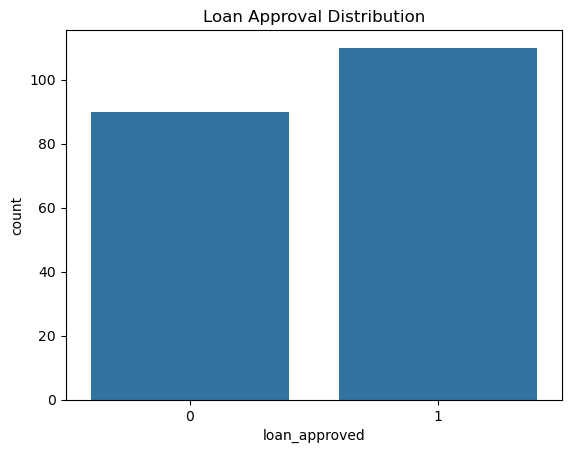

In [10]:
sns.countplot(x='loan_approved', data=loan)
plt.title("Loan Approval Distribution")
plt.show()

In [11]:
loan['loan_approved'].value_counts(normalize= True)

loan_approved
1    0.55
0    0.45
Name: proportion, dtype: float64

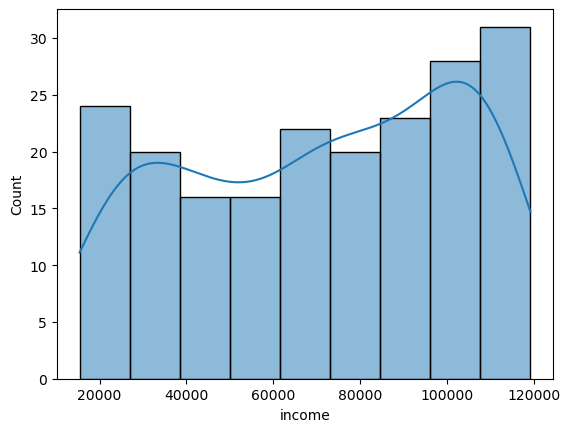

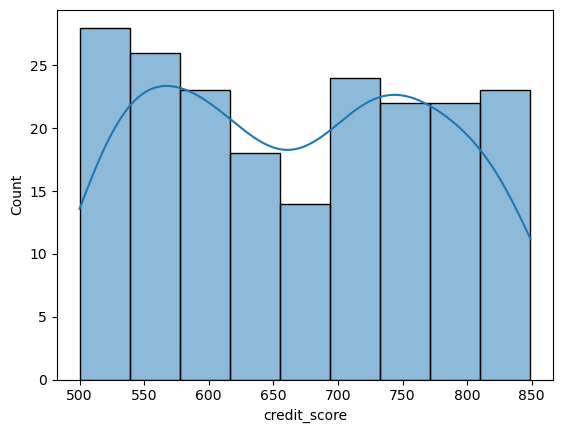

In [12]:
sns.histplot(loan['income'], kde=True)
plt.show()

sns.histplot(loan['credit_score'], kde=True)
plt.show()

In [13]:
nums_col = loan.select_dtypes(include= 'int')
cat_col = loan.select_dtypes(include= 'object')

In [14]:
loan.describe()

,applicant_id,age,income,loan_amount,credit_score,loan_approved
count,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,41.79500,71384.345000,28042.725000,669.195000,0.550000
std,57.879185,11.72306,31437.816323,12922.229297,105.718584,0.498742
min,1.000000,21.00000,15412.000000,5009.000000,500.000000,0.000000
25%,50.750000,31.00000,43104.000000,16430.500000,573.500000,0.000000
50%,100.500000,44.00000,74188.000000,28600.500000,670.500000,1.000000
75%,150.250000,52.00000,101188.250000,39692.750000,756.500000,1.000000
max,200.000000,59.00000,119185.000000,49912.000000,849.000000,1.000000


In [15]:
loan.columns

Index(['applicant_id', 'gender', 'age', 'income', 'loan_amount',
       'credit_score', 'employment_status', 'marital_status', 'loan_approved'],
      dtype='object')

In [16]:
loan['gender'].value_counts()

gender
Male      100
Female    100
Name: count, dtype: int64

In [17]:
loan['employment_status'].value_counts()

employment_status
Unemployed       71
Self-employed    65
Employed         64
Name: count, dtype: int64

In [18]:
loan['marital_status'].value_counts()

marital_status
Single     111
Married     89
Name: count, dtype: int64

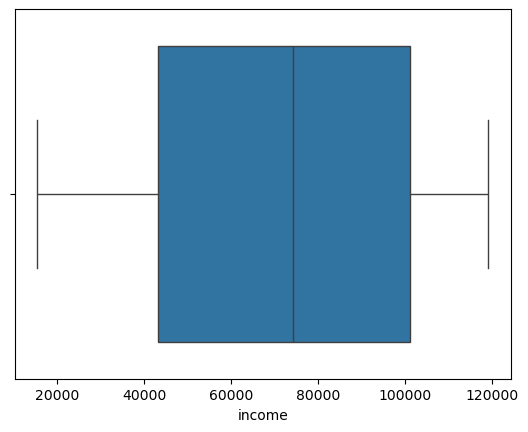

In [19]:
sns.boxplot(x=loan['income'])
plt.show()

In [20]:
x = loan.drop('loan_approved', axis = 1)
y = loan['loan_approved']

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [22]:
loan.columns

Index(['applicant_id', 'gender', 'age', 'income', 'loan_amount',
       'credit_score', 'employment_status', 'marital_status', 'loan_approved'],
      dtype='object')

In [23]:
nums_col = ["age", "income", "loan_amount","credit_score" ]
cat_cols = ["employment_status"]
bin_col = ["marital_status", "gender"]

In [24]:
num_pp = Pipeline([("scaler", StandardScaler())])
cat_pp = Pipeline([("ohe", OneHotEncoder(handle_unknown = 'ignore'))])
bin_pp = Pipeline([("bin", OrdinalEncoder())])

In [25]:
j = ColumnTransformer([
    ("num", num_pp, nums_col),
    ("cat", cat_pp, cat_cols),
    ("bin", bin_pp, bin_col)
])

In [26]:
pipe = Pipeline([("pre", j), ("lr", LogisticRegression())])

In [27]:
pipe.fit(x_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'income',
                                                   'loan_amount',
                                                   'credit_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['employment_status']),
                                                 ('bin',
                                                  Pipeline(steps=[('bin',
                                                                   OrdinalEncoder())]),
                                                  ['marital_status',
                                                   'gender'])])),
                ('lr', LogisticRegression())])

In [28]:
y_prediction = pipe.predict(x_test)

In [29]:
print('accuracy',accuracy_score(y_test, y_prediction))
print('recall', recall_score(y_test, y_prediction))
print('precision', precision_score(y_test, y_prediction))
print('cm', confusion_matrix(y_test, y_prediction))

accuracy 0.875
recall 0.8636363636363636
precision 0.9047619047619048
cm [[16  2]
 [ 3 19]]


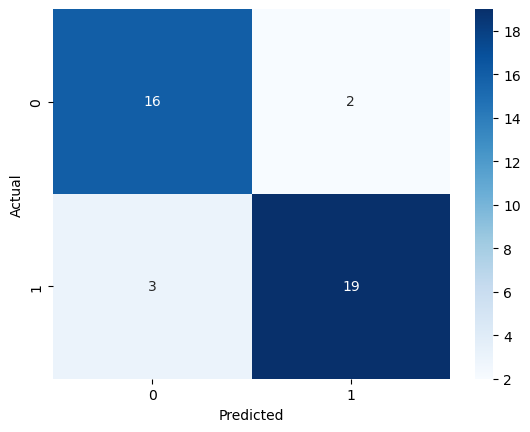

In [38]:
cm = confusion_matrix(y_test, y_prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
new_data = pd.DataFrame({
    'gender': ['Male'],
    'age': [25],
    'income': [50000],
    'loan_amount': [200000],
    'credit_score': [720],
    'employment_status': ['Salaried'],
    'marital_status': ['Married']
})

In [32]:
pipe.predict(new_data)

array([0], dtype=int64)

In [33]:
pipe.predict_proba(new_data)

array([[9.99999995e-01, 4.84991788e-09]])

In [34]:
import joblib

joblib.dump(pipe, "loan_model.pkl")

['loan_model.pkl']